In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fixed = pd.read_csv("../experiment/results_jalur2_fixed_window.csv")
adaptive = pd.read_csv("../experiment/results_adaptive_window.csv")
jalur1 = pd.read_csv("../experiment/results_jalur1_wer_bleu.csv")
comparison = pd.read_csv("../experiment/comparison_summary.csv")

print("Data berhasil dimuat.")
print(f"Fixed: {len(fixed)} baris | Adaptive: {len(adaptive)} baris | Jalur1: {len(jalur1)} baris")

Data berhasil dimuat.
Fixed: 1362 baris | Adaptive: 687 baris | Jalur1: 194 baris


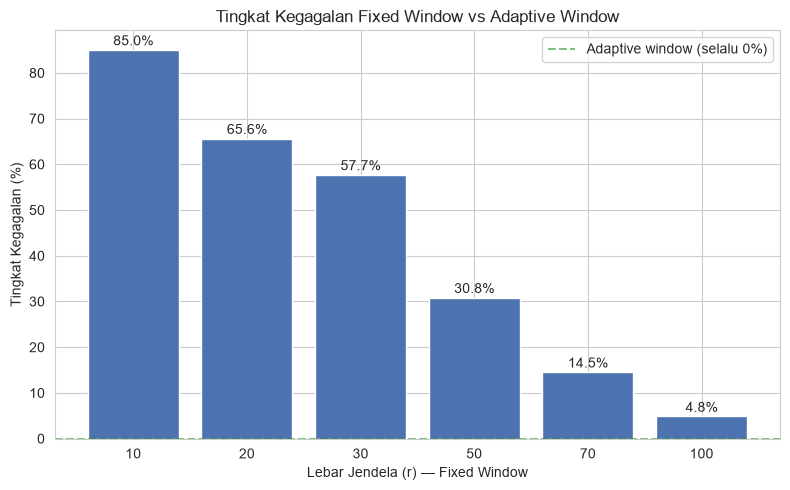

In [2]:
fixed_fail = fixed.groupby("r")["status"].apply(lambda s: (s == "FAILED").mean() * 100).reset_index()
fixed_fail.columns = ["r", "tingkat_gagal_persen"]

plt.figure(figsize=(8, 5))
bars = plt.bar(fixed_fail["r"].astype(str), fixed_fail["tingkat_gagal_persen"], color="#4C72B0")
plt.axhline(0, color="green", linestyle="--", alpha=0.5, label="Adaptive window (selalu 0%)")
plt.xlabel("Lebar Jendela (r) — Fixed Window")
plt.ylabel("Tingkat Kegagalan (%)")
plt.title("Tingkat Kegagalan Fixed Window vs Adaptive Window")
plt.legend()
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
              f"{bar.get_height():.1f}%", ha="center")
plt.tight_layout()
plt.savefig("../experiment/fig_tingkat_kegagalan.png", dpi=150)
plt.show()

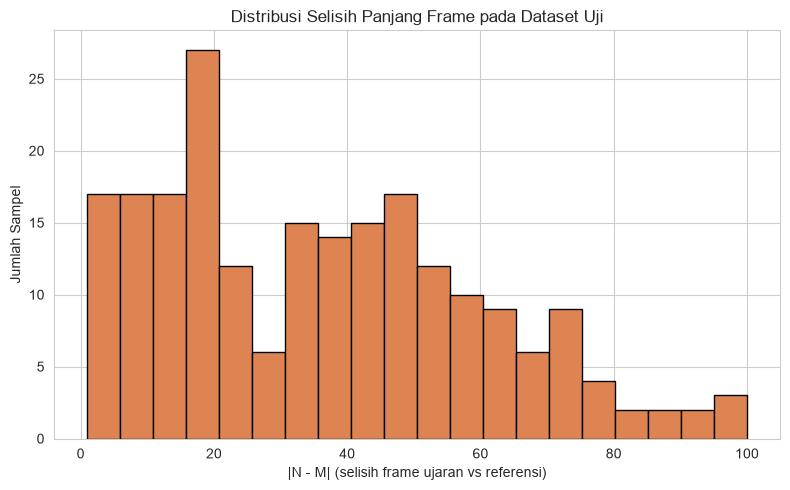

Statistik |N-M|: min=1, median=34, max=100, mean=36.1


In [3]:
fixed_ok = fixed[fixed["status"] == "ok"].copy()
fixed_ok["abs_diff"] = (fixed_ok["N"] - fixed_ok["M"]).abs()
unique_diffs = fixed_ok.drop_duplicates(subset="file")["abs_diff"]

plt.figure(figsize=(8, 5))
plt.hist(unique_diffs, bins=20, color="#DD8452", edgecolor="black")
plt.xlabel("|N - M| (selisih frame ujaran vs referensi)")
plt.ylabel("Jumlah Sampel")
plt.title("Distribusi Selisih Panjang Frame pada Dataset Uji")
plt.tight_layout()
plt.savefig("../experiment/fig_distribusi_selisih.png", dpi=150)
plt.show()

print(f"Statistik |N-M|: min={unique_diffs.min()}, median={unique_diffs.median():.0f}, "
      f"max={unique_diffs.max()}, mean={unique_diffs.mean():.1f}")

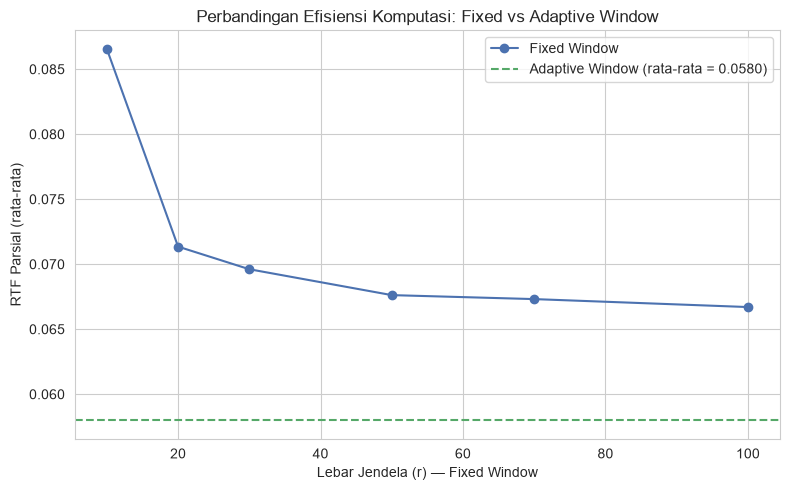

In [4]:
fixed_rtf = fixed[fixed["status"] == "ok"].groupby("r")["rtf_partial"].mean().reset_index()
adaptive_rtf_avg = adaptive[adaptive["status"] == "ok"]["rtf_partial"].mean()

plt.figure(figsize=(8, 5))
plt.plot(fixed_rtf["r"], fixed_rtf["rtf_partial"], marker="o", label="Fixed Window", color="#4C72B0")
plt.axhline(adaptive_rtf_avg, color="#55A868", linestyle="--",
            label=f"Adaptive Window (rata-rata = {adaptive_rtf_avg:.4f})")
plt.xlabel("Lebar Jendela (r) — Fixed Window")
plt.ylabel("RTF Parsial (rata-rata)")
plt.title("Perbandingan Efisiensi Komputasi: Fixed vs Adaptive Window")
plt.legend()
plt.tight_layout()
plt.savefig("../experiment/fig_perbandingan_rtf.png", dpi=150)
plt.show()

=== Ringkasan Jalur 1: WER & BLEU ===
Rata-rata WER : 0.2941 (29.41%)
Rata-rata BLEU: 34.79


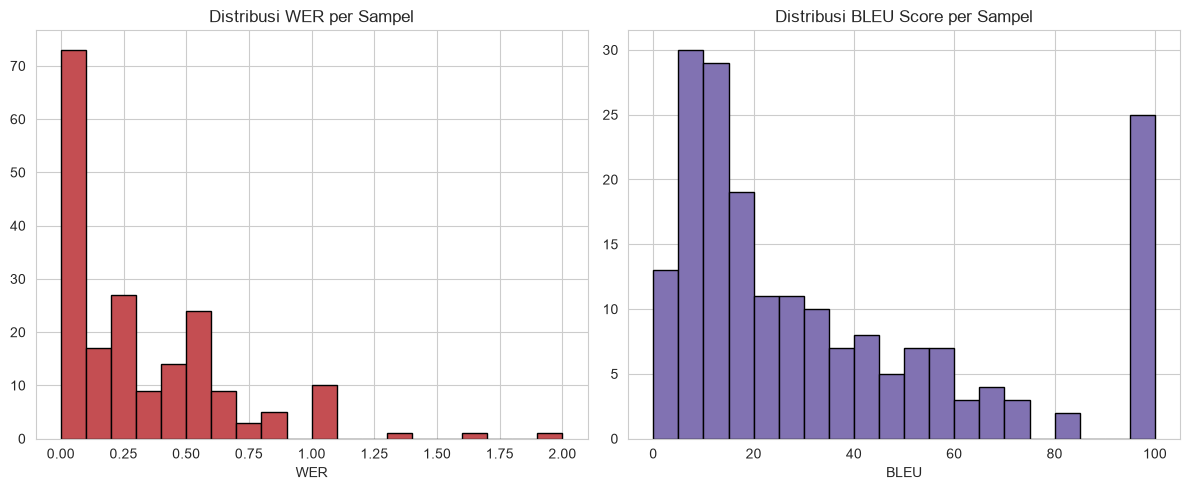

In [5]:
print("=== Ringkasan Jalur 1: WER & BLEU ===")
print(f"Rata-rata WER : {jalur1['wer'].mean():.4f} ({jalur1['wer'].mean()*100:.2f}%)")
print(f"Rata-rata BLEU: {jalur1['bleu'].mean():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(jalur1["wer"], bins=20, color="#C44E52", edgecolor="black")
axes[0].set_title("Distribusi WER per Sampel")
axes[0].set_xlabel("WER")

axes[1].hist(jalur1["bleu"], bins=20, color="#8172B2", edgecolor="black")
axes[1].set_title("Distribusi BLEU Score per Sampel")
axes[1].set_xlabel("BLEU")

plt.tight_layout()
plt.savefig("../experiment/fig_distribusi_wer_bleu.png", dpi=150)
plt.show()

In [6]:
print("=== TABEL RINGKASAN UNTUK BAB IV ===\n")
display_cols = ["mode", "parameter", "tingkat_gagal_persen", "avg_normalized_distance", "avg_rtf_partial"]
print(comparison[display_cols].to_string(index=False))

comparison.to_html("../experiment/tabel_perbandingan.html", index=False)
print("\nTabel juga disimpan sebagai HTML: experiment/tabel_perbandingan.html (bisa dibuka & di-copy ke Word)")

=== TABEL RINGKASAN UNTUK BAB IV ===

    mode  parameter  tingkat_gagal_persen  avg_normalized_distance  avg_rtf_partial
   fixed         10                 83.41                 4.429807         0.053664
   fixed         20                 65.50                 4.366748         0.064661
   fixed         30                 48.91                 4.300783         0.060215
   fixed         50                 22.27                 4.203506         0.058965
   fixed         70                  9.61                 4.134066         0.058682
   fixed        100                  3.06                 4.132189         0.059154
adaptive          1                  0.00                 4.141345         0.058915
adaptive          2                  0.00                 4.141345         0.059416
adaptive          5                  0.00                 4.141345         0.058401

Tabel juga disimpan sebagai HTML: experiment/tabel_perbandingan.html (bisa dibuka & di-copy ke Word)


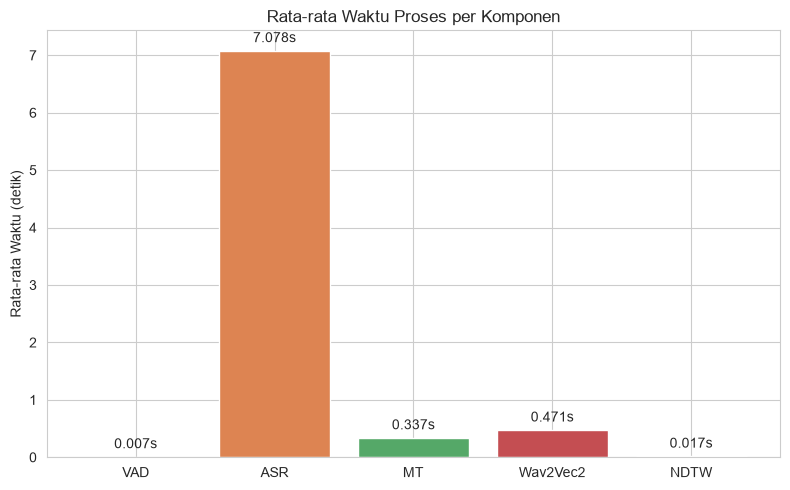

Rata-rata waktu per komponen (detik):
VAD         0.00700
ASR         7.07800
MT          0.33675
Wav2Vec2    0.47150
NDTW        0.01700
dtype: float64


In [13]:
demo_data = pd.DataFrame([
    {"percobaan": "P1", "VAD": 0.012, "ASR": 8.14, "MT": 0.397, "Wav2Vec2": 0.635, "NDTW": 0.033},
    {"percobaan": "P2", "VAD": 0.005, "ASR": 7.266, "MT": 0.425, "Wav2Vec2": 0.411, "NDTW": 0.004},
    {"percobaan": "P3", "VAD": 0.006, "ASR": 7.287, "MT": 0.328, "Wav2Vec2": 0.424, "NDTW": 0.028},
    {"percobaan": "P4", "VAD": 0.005, "ASR": 5.619, "MT": 0.197, "Wav2Vec2": 0.416, "NDTW": 0.003},
])

komponen = ["VAD", "ASR", "MT", "Wav2Vec2", "NDTW"]
avg_waktu = demo_data[komponen].mean()
persentase = (avg_waktu / avg_waktu.sum() * 100).round(2)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

plt.figure(figsize=(8, 5))
plt.bar(komponen, avg_waktu, color=colors)
plt.ylabel("Rata-rata Waktu (detik)")
plt.title("Rata-rata Waktu Proses per Komponen")
for i, v in enumerate(avg_waktu):
    plt.text(i, v + 0.15, f"{v:.3f}s", ha="center")
plt.tight_layout()
plt.savefig("../experiment/fig_breakdown_waktu.png", dpi=150)
plt.show()

print("Rata-rata waktu per komponen (detik):")
print(avg_waktu)

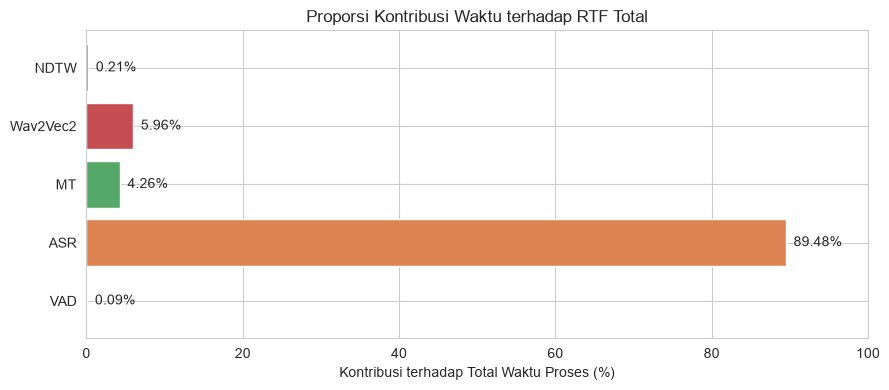


Rincian persentase kontribusi:
  VAD       : 0.09%
  ASR       : 89.48%
  MT        : 4.26%
  Wav2Vec2  : 5.96%
  NDTW      : 0.21%


In [14]:
plt.figure(figsize=(9, 4))
bars = plt.barh(komponen, persentase, color=colors)
plt.xlabel("Kontribusi terhadap Total Waktu Proses (%)")
plt.title("Proporsi Kontribusi Waktu terhadap RTF Total")
for i, (k, p) in enumerate(zip(komponen, persentase)):
    plt.text(p + 1, i, f"{p:.2f}%", va="center", fontsize=10)
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig("../experiment/fig_proporsi_waktu.png", dpi=150)
plt.show()

print("\nRincian persentase kontribusi:")
for k, p in zip(komponen, persentase):
    print(f"  {k:10s}: {p:.2f}%")

In [8]:
error_examples = pd.DataFrame([
    {"Jenis Kesalahan": "Repetition Loop", "Ground Truth": "Tom hampir saja terbunuh.",
     "Hasil ASR": "Terima kasih sudah menonton video ini. (diulang 35x)", "WER": 52.5},
    {"Jenis Kesalahan": "Substitusi Fonetik (Near-homophone)", "Ground Truth": "Halo tuan, bagaimana kabarmu?",
     "Hasil ASR": "Halo Tuhan, bagaimana kabarmu?", "WER": 0.25},
    {"Jenis Kesalahan": "Segmentasi Batas Kata", "Ground Truth": "...bagaimana kabarmu?",
     "Hasil ASR": "...bagaimana Kak Permu?", "WER": 0.40},
])
print(error_examples.to_string(index=False))
error_examples.to_html("../experiment/tabel_contoh_kesalahan.html", index=False)

                    Jenis Kesalahan                  Ground Truth                                            Hasil ASR   WER
                    Repetition Loop     Tom hampir saja terbunuh. Terima kasih sudah menonton video ini. (diulang 35x) 52.50
Substitusi Fonetik (Near-homophone) Halo tuan, bagaimana kabarmu?                       Halo Tuhan, bagaimana kabarmu?  0.25
              Segmentasi Batas Kata         ...bagaimana kabarmu?                              ...bagaimana Kak Permu?  0.40
